In [126]:
# Imports we have used so far
import numpy as np
import pandas as pd
from matplotlib.pyplot import subplots
import statsmodels.api as sm
from ISLP import load_data
from ISLP.models import (ModelSpec as MS, summarize)

In [2]:
# New imports
from ISLP import confusion_table
from ISLP.models import contrast
from sklearn.discriminant_analysis import (LinearDiscriminantAnalysis as LDA, QuadraticDiscriminantAnalysis as QDA)
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

In [3]:
Smarket = load_data('Smarket')

In [4]:
Smarket.columns

Index(['Year', 'Lag1', 'Lag2', 'Lag3', 'Lag4', 'Lag5', 'Volume', 'Today',
       'Direction'],
      dtype='object')

In [5]:
Smarket.head

<bound method NDFrame.head of       Year   Lag1   Lag2   Lag3   Lag4   Lag5   Volume  Today Direction
0     2001  0.381 -0.192 -2.624 -1.055  5.010  1.19130  0.959        Up
1     2001  0.959  0.381 -0.192 -2.624 -1.055  1.29650  1.032        Up
2     2001  1.032  0.959  0.381 -0.192 -2.624  1.41120 -0.623      Down
3     2001 -0.623  1.032  0.959  0.381 -0.192  1.27600  0.614        Up
4     2001  0.614 -0.623  1.032  0.959  0.381  1.20570  0.213        Up
...    ...    ...    ...    ...    ...    ...      ...    ...       ...
1245  2005  0.422  0.252 -0.024 -0.584 -0.285  1.88850  0.043        Up
1246  2005  0.043  0.422  0.252 -0.024 -0.584  1.28581 -0.955      Down
1247  2005 -0.955  0.043  0.422  0.252 -0.024  1.54047  0.130        Up
1248  2005  0.130 -0.955  0.043  0.422  0.252  1.42236 -0.298      Down
1249  2005 -0.298  0.130 -0.955  0.043  0.422  1.38254 -0.489      Down

[1250 rows x 9 columns]>

In [6]:
# Assuming 'df' is your DataFrame
correlation_matrix = Smarket.corr(numeric_only=True)

# Display the correlation matrix
print(correlation_matrix)

            Year      Lag1      Lag2      Lag3      Lag4      Lag5    Volume  \
Year    1.000000  0.029700  0.030596  0.033195  0.035689  0.029788  0.539006   
Lag1    0.029700  1.000000 -0.026294 -0.010803 -0.002986 -0.005675  0.040910   
Lag2    0.030596 -0.026294  1.000000 -0.025897 -0.010854 -0.003558 -0.043383   
Lag3    0.033195 -0.010803 -0.025897  1.000000 -0.024051 -0.018808 -0.041824   
Lag4    0.035689 -0.002986 -0.010854 -0.024051  1.000000 -0.027084 -0.048414   
Lag5    0.029788 -0.005675 -0.003558 -0.018808 -0.027084  1.000000 -0.022002   
Volume  0.539006  0.040910 -0.043383 -0.041824 -0.048414 -0.022002  1.000000   
Today   0.030095 -0.026155 -0.010250 -0.002448 -0.006900 -0.034860  0.014592   

           Today  
Year    0.030095  
Lag1   -0.026155  
Lag2   -0.010250  
Lag3   -0.002448  
Lag4   -0.006900  
Lag5   -0.034860  
Volume  0.014592  
Today   1.000000  


<Axes: >

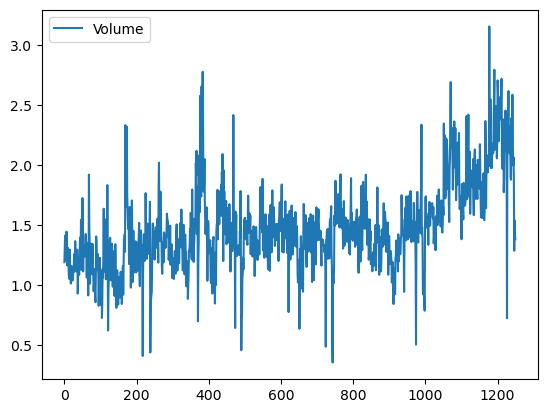

In [7]:
Smarket.plot(y='Volume')

In [8]:
allvars = Smarket.columns.drop(['Today','Direction','Year'])
design = MS(allvars)
X=design.fit_transform(Smarket)
y= Smarket.Direction == 'Up'
glm =sm.GLM(y,
    X,
    family = sm.families.Binomial()
)
results = glm.fit()
summarize(results)

,coef,std err,z,P>|z|
intercept,-0.1260,0.241,-0.523,0.601
Lag1,-0.0731,0.050,-1.457,0.145
Lag2,-0.0423,0.050,-0.845,0.398
Lag3,0.0111,0.050,0.222,0.824
Lag4,0.0094,0.050,0.187,0.851
Lag5,0.0103,0.050,0.208,0.835
Volume,0.1354,0.158,0.855,0.392


In [9]:
results.params

intercept   -0.126000
Lag1        -0.073074
Lag2        -0.042301
Lag3         0.011085
Lag4         0.009359
Lag5         0.010313
Volume       0.135441
dtype: float64

In [10]:
results.pvalues

intercept    0.600700
Lag1         0.145232
Lag2         0.398352
Lag3         0.824334
Lag4         0.851445
Lag5         0.834998
Volume       0.392404
dtype: float64

In [11]:
probs = results.predict()
probs[:10]

array([0.50708413, 0.48146788, 0.48113883, 0.51522236, 0.51078116,
       0.50695646, 0.49265087, 0.50922916, 0.51761353, 0.48883778])

In [12]:
labels = np.array(['Down']*1250)
labels[probs>0.5] = 'Up'

In [13]:
confusion_table(labels,Smarket.Direction)

Truth,Down,Up
Predicted,,
Down,145,141
Up,457,507


In [14]:
(507+145)/1250, np.mean(labels == Smarket.Direction)

(0.5216, 0.5216)

In [15]:
train = (Smarket.Year<2005)
Smarket_train = Smarket.loc[train]
Smarket_test = Smarket.loc[~train]
Smarket_test.shape

(252, 9)

In [16]:
X_train, X_test, = X.loc[train], X.loc[~train]
y_train, y_test, = y.loc[train], y.loc[~train]
glm_train = sm.GLM(y_train, X_train, family=sm.families.Binomial())
results = glm_train.fit()
probs = results.predict(exog=X_test)

In [17]:
D = Smarket.Direction
L_train, L_test = D.loc[train], D.loc[~train]


In [18]:
labels = np.array(['Down']*252)
labels[probs>0.5]='Up'
confusion_table(labels,L_test)

Truth,Down,Up
Predicted,,
Down,77,97
Up,34,44


In [19]:
np.mean(labels == L_test), np.mean(labels != L_test)

(0.4801587301587302, 0.5198412698412699)

In [20]:
model = MS(['Lag1','Lag2']).fit(Smarket)
X = model.transform(Smarket)
X_train , X_test = X.loc[train],X.loc[~train]
glm_train = sm.GLM(y_train,X_train, family=sm.families.Binomial())
results = glm_train.fit()
probs = results.predict(exog=X_test)
labels = np.array(['Down']*252)
labels[probs>0.5]='Up'
confusion_table(labels,L_test)

Truth,Down,Up
Predicted,,
Down,35,35
Up,76,106


In [21]:
(35+106)/252,106/(106+76)

(0.5595238095238095, 0.5824175824175825)

In [22]:
newdata = pd.DataFrame({'Lag1':[1.2,1.5],'Lag2':[1.1,-0.8]})
newX = model.transform(newdata)
results.predict(newX)

0    0.479146
1    0.496094
dtype: float64

In [23]:
lda = LDA(store_covariance=True)

In [24]:
X_train, X_test = (M.drop(columns=['intercept'])
                  for M in [X_train,X_test])

In [25]:
lda.fit(X_train,L_train)

LinearDiscriminantAnalysis(store_covariance=True)

In [26]:
?lda.fit

Signature: lda.fit(X, y)
Docstring:
Fit the Linear Discriminant Analysis model.

.. versionchanged:: 0.19
    `store_covariance` and `tol` has been moved to main constructor.

Parameters
----------
X : array-like of shape (n_samples, n_features)
    Training data.

y : array-like of shape (n_samples,)
    Target values.

Returns
-------
self : object
    Fitted estimator.
File:      ~/anaconda3/lib/python3.12/site-packages/sklearn/discriminant_analysis.py
Type:      method

In [27]:
lda.means_

array([[ 0.04279022,  0.03389409],
       [-0.03954635, -0.03132544]])

In [28]:
lda.classes_

array(['Down', 'Up'], dtype='<U4')

In [29]:
lda.priors_

array([0.49198397, 0.50801603])

In [30]:
lda.scalings_

array([[-0.64201904],
       [-0.51352928]])

In [31]:
lda_pred = lda.predict(X_test)

In [32]:
confusion_table(lda_pred, L_test)

Truth,Down,Up
Predicted,,
Down,35,35
Up,76,106


In [33]:
lda_prob = lda.predict_proba(X_test)
np.all(np.where(lda_prob[:,1]>=0.5,"Up",'Down')== lda_pred)

True

In [34]:
?np.all

Signature:       np.all(a, axis=None, out=None, keepdims=<no value>, *, where=<no value>)
Call signature:  np.all(*args, **kwargs)
Type:            _ArrayFunctionDispatcher
String form:     <function all at 0x7f15ced407c0>
File:            ~/anaconda3/lib/python3.12/site-packages/numpy/core/fromnumeric.py
Docstring:      
Test whether all array elements along a given axis evaluate to True.

Parameters
----------
a : array_like
    Input array or object that can be converted to an array.
axis : None or int or tuple of ints, optional
    Axis or axes along which a logical AND reduction is performed.
    The default (``axis=None``) is to perform a logical AND over all
    the dimensions of the input array. `axis` may be negative, in
    which case it counts from the last to the first axis.

    .. versionadded:: 1.7.0

    If this is a tuple of ints, a reduction is performed on multiple
    axes, instead of a single axis or all the axes as before.
out : ndarray, optional
    Alternate out

In [35]:
np.all([lda.classes_[i] for i in np.argmax(lda_prob,1)] == lda_pred)

True

In [36]:
np.sum(lda_prob[:,0]>0.9)

0

In [37]:
qda = QDA(store_covariance=True)
qda.fit(X_train, L_train)

QuadraticDiscriminantAnalysis(store_covariance=True)

In [38]:
qda.means_, qda.priors_

(array([[ 0.04279022,  0.03389409],
        [-0.03954635, -0.03132544]]),
 array([0.49198397, 0.50801603]))

In [39]:
qda.covariance_

[array([[ 1.50662277, -0.03924806],
        [-0.03924806,  1.53559498]]),
 array([[ 1.51700576, -0.02787349],
        [-0.02787349,  1.49026815]])]

In [40]:
qda_pred = qda.predict(X_test)
confusion_table(qda_pred, L_test)

Truth,Down,Up
Predicted,,
Down,30,20
Up,81,121


In [41]:
np.mean(qda_pred == L_test)

0.5992063492063492

In [42]:
NB=GaussianNB()
NB.fit(X_train,L_train)


GaussianNB()

In [43]:
NB.classes_

array(['Down', 'Up'], dtype='<U4')

In [44]:
NB.class_prior_

array([0.49198397, 0.50801603])

In [45]:
NB.theta_

array([[ 0.04279022,  0.03389409],
       [-0.03954635, -0.03132544]])

In [46]:
NB.var_

array([[1.50355429, 1.53246749],
       [1.51401364, 1.48732877]])

In [47]:
X_train[L_train == 'Down'].mean()

Lag1    0.042790
Lag2    0.033894
dtype: float64

In [48]:
X_train[L_train == 'Down'].var(ddof=0)

Lag1    1.503554
Lag2    1.532467
dtype: float64

In [49]:
nb_labels = NB.predict(X_test)
confusion_table(nb_labels,L_test)

Truth,Down,Up
Predicted,,
Down,29,20
Up,82,121


In [86]:
NB.predict_proba(X_test)[:5]

array([[0.4873288 , 0.5126712 ],
       [0.47623584, 0.52376416],
       [0.46529531, 0.53470469],
       [0.47484469, 0.52515531],
       [0.49020587, 0.50979413]])

In [88]:
knn1=KNeighborsClassifier(n_neighbors=1)
knn1.fit(X_train,L_train)
knn1_pred = knn1.predict(X_test)
confusion_table(knn1_pred,L_test)


Truth,Down,Up
Predicted,,
Down,43,58
Up,68,83


In [89]:
(83+43)/252, np.mean(knn1_pred == L_test)

(0.5, 0.5)

In [94]:
knn3=KNeighborsClassifier(n_neighbors=3)
knn3_pred = knn3.fit(X_train,L_train).predict(X_test)
np.mean(knn3_pred == L_test)

0.5317460317460317

In [95]:
Caravan = load_data('Caravan')
Purchase = Caravan.Purchase
Purchase.value_counts()

Purchase
No     5474
Yes     348
Name: count, dtype: int64

In [96]:
feature_df = Caravan.drop(columns=['Purchase'])


In [97]:
scaler = StandardScaler(with_mean=True,with_std=True,copy=True )

In [101]:
L_test.head

<bound method NDFrame.head of 998     Down
999     Down
1000    Down
1001      Up
1002    Down
        ... 
1245      Up
1246    Down
1247      Up
1248    Down
1249    Down
Name: Direction, Length: 252, dtype: category
Categories (2, object): ['Down', 'Up']>

In [102]:
scaler.fit(feature_df)
X_std = scaler.transform(feature_df)

In [103]:
feature_std = pd.DataFrame(X_std, columns = feature_df.columns)
feature_std.std()

MOSTYPE     1.000086
MAANTHUI    1.000086
MGEMOMV     1.000086
MGEMLEEF    1.000086
MOSHOOFD    1.000086
              ...   
AZEILPL     1.000086
APLEZIER    1.000086
AFIETS      1.000086
AINBOED     1.000086
ABYSTAND    1.000086
Length: 85, dtype: float64

In [104]:
(X_train, X_test, y_train, y_test)= train_test_split(feature_std,Purchase, test_size=1000, random_state = 0)

In [105]:
knn1 = KNeighborsClassifier(n_neighbors=1)
knn1_pred = knn1.fit(X_train, y_train).predict(X_test)
np.mean(y_test != knn1_pred), np.mean(y_test!='No')

(0.11, 0.067)

In [106]:
confusion_table(knn1_pred, y_test)

Truth,No,Yes
Predicted,,
No,881,58
Yes,52,9


In [112]:
for K in range(1,6):
    knn = KNeighborsClassifier(n_neighbors=K)
    knn_pred = knn.fit(X_train,y_train).predict(X_test)
    C = confusion_table(knn_pred,y_test)
    temp1=('K={0:d}: # predicted to rent: {1:>2},'+
    ' # who did rent {2:d}, accuracy {3:.1%}')
    pred = C.loc['Yes'].sum()
    did_rent = C.loc['Yes','Yes']
    print(temp1.format(
        K,pred,did_rent,did_rent/pred
    ))

K=1: # predicted to rent: 61, # who did rent 9, accuracy 14.8%
K=2: # predicted to rent:  6, # who did rent 1, accuracy 16.7%
K=3: # predicted to rent: 20, # who did rent 3, accuracy 15.0%
K=4: # predicted to rent:  3, # who did rent 0, accuracy 0.0%
K=5: # predicted to rent:  7, # who did rent 1, accuracy 14.3%


In [114]:
logit = LogisticRegression(C=1e10, solver='liblinear')
logit.fit(X_train,y_train)
logit_pred= logit.predict_proba(X_test)
logit_labels = np.where(logit_pred[:,1]>5, 'Yes','No')
confusion_table(logit_labels,y_test)

Truth,No,Yes
Predicted,,
No,933,67
Yes,0,0


In [115]:
logit_labels = np.where(logit_pred[:,1]>0.25,'Yes','No')
confusion_table(logit_labels, y_test)

Truth,No,Yes
Predicted,,
No,913,58
Yes,20,9


In [122]:
Bike = load_data('Bikeshare')

In [123]:
Bike.shape, Bike.columns

((8645, 15),
 Index(['season', 'mnth', 'day', 'hr', 'holiday', 'weekday', 'workingday',
        'weathersit', 'temp', 'atemp', 'hum', 'windspeed', 'casual',
        'registered', 'bikers'],
       dtype='object'))

In [129]:
X = MS(['mnth',
        'hr',
        'workingday',
        'temp',
        'weathersit']).fit_transform(Bike)
Y=Bike['bikers']
M_lm = sm.OLS(Y,X).fit()
summarize(M_lm)

,coef,std err,t,P>|t|
intercept,-68.6317,5.307,-12.932,0.000
mnth[Feb],6.8452,4.287,1.597,0.110
mnth[March],16.5514,4.301,3.848,0.000
mnth[April],41.4249,4.972,8.331,0.000
mnth[May],72.5571,5.641,12.862,0.000
mnth[June],67.8187,6.544,10.364,0.000
mnth[July],45.3245,7.081,6.401,0.000
mnth[Aug],53.2430,6.640,8.019,0.000
mnth[Sept],66.6783,5.925,11.254,0.000
mnth[Oct],75.8343,4.950,15.319,0.000


In [130]:
hr_encode = contrast('hr','sum')
mnth_encode = contrast('mnth','sum')

In [134]:
X2 = MS([mnth_encode,hr_encode,'workingday','temp','weathersit']).fit_transform(Bike)
M2_lm = sm.OLS(Y,X2).fit()
S2 = summarize(M2_lm)
S2

,coef,std err,t,P>|t|
intercept,73.5974,5.132,14.340,0.000
mnth[Jan],-46.0871,4.085,-11.281,0.000
mnth[Feb],-39.2419,3.539,-11.088,0.000
mnth[March],-29.5357,3.155,-9.361,0.000
mnth[April],-4.6622,2.741,-1.701,0.089
mnth[May],26.4700,2.851,9.285,0.000
mnth[June],21.7317,3.465,6.272,0.000
mnth[July],-0.7626,3.908,-0.195,0.845
mnth[Aug],7.1560,3.535,2.024,0.043
mnth[Sept],20.5912,3.046,6.761,0.000


In [136]:
np.sum((M_lm.fittedvalues-M2_lm.fittedvalues)**2)

2.090347015370735e-19

In [137]:
?np.sum

Signature:      
np.sum(
    a,
    axis=None,
    dtype=None,
    out=None,
    keepdims=<no value>,
    initial=<no value>,
    where=<no value>,
)
Call signature:  np.sum(*args, **kwargs)
Type:            _ArrayFunctionDispatcher
String form:     <function sum at 0x7f15ced40540>
File:            ~/anaconda3/lib/python3.12/site-packages/numpy/core/fromnumeric.py
Docstring:      
Sum of array elements over a given axis.

Parameters
----------
a : array_like
    Elements to sum.
axis : None or int or tuple of ints, optional
    Axis or axes along which a sum is performed.  The default,
    axis=None, will sum all of the elements of the input array.  If
    axis is negative it counts from the last to the first axis.

    .. versionadded:: 1.7.0

    If axis is a tuple of ints, a sum is performed on all of the axes
    specified in the tuple instead of a single axis or all the axes as
    before.
dtype : dtype, optional
    The type of the returned array and of the accumulator in which t

In [138]:
?M_lm.fittedvalues

Type:        Series
String form:
0       -30.901456
           1       -48.624910
           2       -55.624782
           3       -62.042212
           4       -67.808961
           <...>  169.403071
           8642    128.263439
           8643     96.688170
           8644     61.258905
           Length: 8645, dtype: float64
Length:      8645
File:        ~/anaconda3/lib/python3.12/site-packages/pandas/core/series.py
Docstring:  
One-dimensional ndarray with axis labels (including time series).

Labels need not be unique but must be a hashable type. The object
supports both integer- and label-based indexing and provides a host of
methods for performing operations involving the index. Statistical
methods from ndarray have been overridden to automatically exclude
missing data (currently represented as NaN).

Operations between Series (+, -, /, \*, \*\*) align values based on their
associated index values-- they need not be the same length. The result
index will be the sorted union of

In [139]:
?np.allclose

Signature:       np.allclose(a, b, rtol=1e-05, atol=1e-08, equal_nan=False)
Call signature:  np.allclose(*args, **kwargs)
Type:            _ArrayFunctionDispatcher
String form:     <function allclose at 0x7f15ced4c680>
File:            ~/anaconda3/lib/python3.12/site-packages/numpy/core/numeric.py
Docstring:      
Returns True if two arrays are element-wise equal within a tolerance.

The tolerance values are positive, typically very small numbers.  The
relative difference (`rtol` * abs(`b`)) and the absolute difference
`atol` are added together to compare against the absolute difference
between `a` and `b`.

NaNs are treated as equal if they are in the same place and if
``equal_nan=True``.  Infs are treated as equal if they are in the same
place and of the same sign in both arrays.

Parameters
----------
a, b : array_like
    Input arrays to compare.
rtol : float
    The relative tolerance parameter (see Notes).
atol : float
    The absolute tolerance parameter (see Notes).
equal_nan :

In [140]:
np.allclose(M_lm.fittedvalues, M2_lm.fittedvalues)

True

In [141]:
coef_month = S2[S2.index.str.contains('mnth')]['coef']
coef_month

mnth[Jan]     -46.0871
mnth[Feb]     -39.2419
mnth[March]   -29.5357
mnth[April]    -4.6622
mnth[May]      26.4700
mnth[June]     21.7317
mnth[July]     -0.7626
mnth[Aug]       7.1560
mnth[Sept]     20.5912
mnth[Oct]      29.7472
mnth[Nov]      14.2229
Name: coef, dtype: float64

In [142]:
-np.sum(coef_month)

0.3705000000000105

In [144]:
months = Bike['mnth'].dtype.categories
coef_month = pd.concat([coef_month,pd.Series([-coef_month.sum()],index=['mnth[Dec]'])])
coef_month

mnth[Jan]     -46.0871
mnth[Feb]     -39.2419
mnth[March]   -29.5357
mnth[April]    -4.6622
mnth[May]      26.4700
mnth[June]     21.7317
mnth[July]     -0.7626
mnth[Aug]       7.1560
mnth[Sept]     20.5912
mnth[Oct]      29.7472
mnth[Nov]      14.2229
mnth[Dec]       0.3705
dtype: float64

Text(0, 0.5, 'Coeficient')

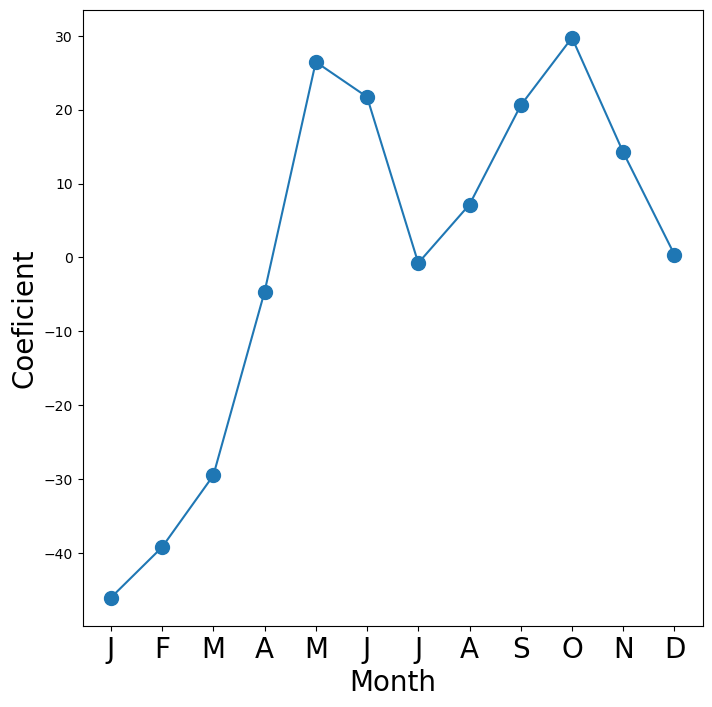

In [145]:
fig_month, ax_month = subplots(figsize = (8,8))
x_month = np.arange(coef_month.shape[0])
ax_month.plot(x_month, coef_month,marker='o',ms=10)
ax_month.set_xticks(x_month)
ax_month.set_xticklabels([l[5] for l in coef_month.index],fontsize=20)
ax_month.set_xlabel('Month', fontsize =20)
ax_month.set_ylabel('Coeficient', fontsize =20)

In [148]:
coef_hr = S2[S2.index.str.contains('hr')]['coef']
coef_hr = coef_hr.reindex(['hr[{0}]'.format(h) for h in range(23)])
coef_hr = pd.concat([coef_hr, pd.Series([-coef_hr.sum()], index = ['hr[23]'])])

Text(0, 0.5, 'Coefficient')

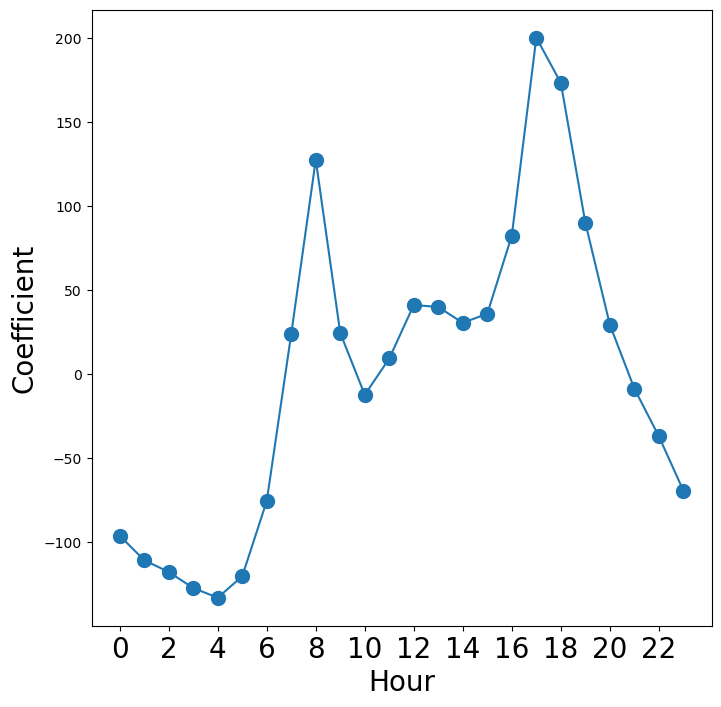

In [153]:
fig_hr, ax_hr = subplots(figsize = (8,8))
x_hr = np.arange(coef_hr.shape[0])
ax_hr.plot(x_hr, coef_hr, marker='o' , ms = 10)
ax_hr.set_xticks(x_hr[::2])
ax_hr.set_xticklabels(range(24)[::2], fontsize=20)
ax_hr.set_xlabel('Hour',fontsize=20)
ax_hr.set_ylabel('Coefficient',fontsize=20)

In [154]:
M_pois = sm.GLM(Y,X2, family = sm.families.Poisson()).fit()

In [156]:
S_pois = summarize(M_pois)
coef_month = S_pois[S_pois.index.str.contains('mnth')]['coef']
coef_month = pd.concat([coef_month, 
                       pd.Series([-coef_month.sum()],
                                index = ['mnth[Dec]'])])
coef_hr = S_pois[S_pois.index.str.contains('hr')]['coef']
coef_hr = pd.concat([coef_hr,
                    pd.Series([-coef_hr.sum()],
                             index=['hr[23]'])])

Text(0, 0.5, 'Coefficient')

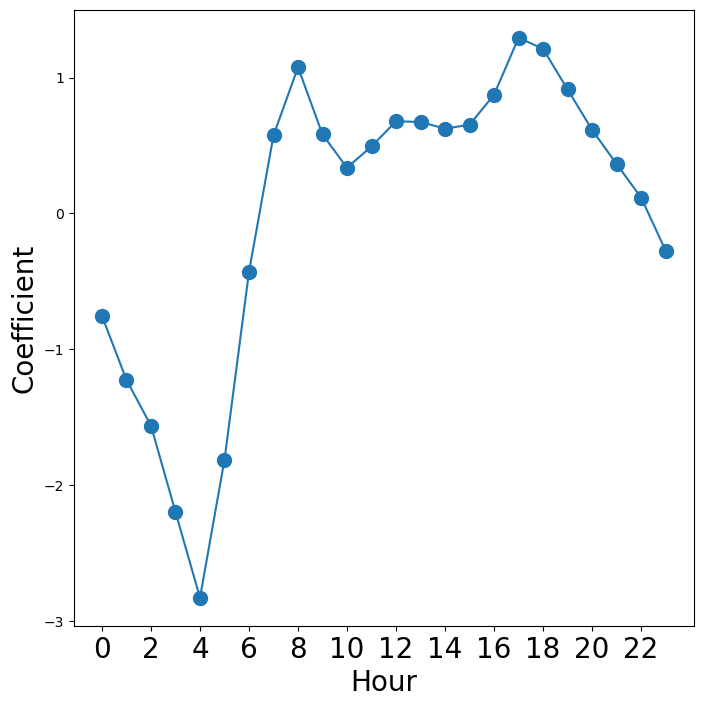

In [157]:
fig_hr, ax_hr = subplots(figsize = (8,8))
x_hr = np.arange(coef_hr.shape[0])
ax_hr.plot(x_hr, coef_hr, marker='o' , ms = 10)
ax_hr.set_xticks(x_hr[::2])
ax_hr.set_xticklabels(range(24)[::2], fontsize=20)
ax_hr.set_xlabel('Hour',fontsize=20)
ax_hr.set_ylabel('Coefficient',fontsize=20)

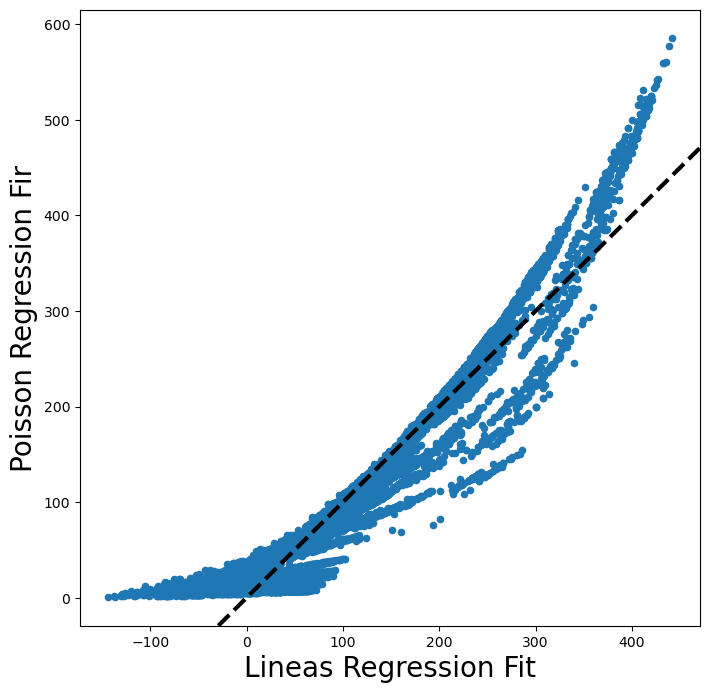

In [158]:
fig,ax = subplots(figsize=(8,8))
ax.scatter(M2_lm.fittedvalues,
           M_pois.fittedvalues, s=20)
ax.set_xlabel('Lineas Regression Fit', fontsize=20)
ax.set_ylabel('Poisson Regression Fir', fontsize =20)
ax.axline([0,0], c='black', linewidth =3, linestyle = '--', slope =1)